In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, OneHotEncoder

In [3]:
df = pd.read_csv('bank_transactions_data_2.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

In [6]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [7]:
# Convert 'TransactionDate' and 'PreviousTransactionDate' to datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Extract year, month, day, and time for 'TransactionDate'
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionDay'] = df['TransactionDate'].dt.day
df['TransactionHourDecimal'] = df['TransactionDate'].dt.hour + df['TransactionDate'].dt.minute / 60 + df['TransactionDate'].dt.second / 3600

# Extract year, month, day, and time for 'PreviousTransactionDate'
df['PrevTransactionYear'] = df['PreviousTransactionDate'].dt.year
df['PrevTransactionMonth'] = df['PreviousTransactionDate'].dt.month
df['PrevTransactionDay'] = df['PreviousTransactionDate'].dt.day
df['PrevTransactionHourDecimal'] = df['PreviousTransactionDate'].dt.hour + df['PreviousTransactionDate'].dt.minute / 60 + df['PreviousTransactionDate'].dt.second / 3600

# Drop the original date columns as their components have been extracted
df = df.drop(columns=['TransactionDate', 'PreviousTransactionDate'])

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,...,LoginAttempts,AccountBalance,TransactionYear,TransactionMonth,TransactionDay,TransactionHourDecimal,PrevTransactionYear,PrevTransactionMonth,PrevTransactionDay,PrevTransactionHourDecimal
0,TX000001,AC00128,14.09,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,...,1,5112.21,2023,4,11,16.487222,2024,11,4,8.135556
1,TX000002,AC00455,376.24,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,...,1,13758.91,2023,6,27,16.738611,2024,11,4,8.159722
2,TX000003,AC00019,126.29,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,...,1,1122.35,2023,7,10,18.268889,2024,11,4,8.117778
3,TX000004,AC00070,184.50,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,...,1,8569.06,2023,5,5,16.536389,2024,11,4,8.151667
4,TX000005,AC00411,13.45,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,...,1,7429.40,2023,10,16,17.856667,2024,11,4,8.110833


In [8]:
df.shape

(2512, 22)

In [9]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionType',
       'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel',
       'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'TransactionYear',
       'TransactionMonth', 'TransactionDay', 'TransactionHourDecimal',
       'PrevTransactionYear', 'PrevTransactionMonth', 'PrevTransactionDay',
       'PrevTransactionHourDecimal'],
      dtype='str')

In [10]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionYear,TransactionMonth,TransactionDay,TransactionHourDecimal,PrevTransactionYear,PrevTransactionMonth,PrevTransactionDay,PrevTransactionHourDecimal
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.00000,2512.000000,2512.000000,2512.0,2512.0,2512.0,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966,2023.005175,6.56250,15.827229,17.125513,2024.0,11.0,4.0,8.156172
std,291.946243,17.792198,69.963757,0.602662,3900.942499,0.071766,3.47559,8.761293,0.786276,0.0,0.0,0.0,0.028718
min,0.260000,18.000000,10.000000,1.000000,101.250000,2023.000000,1.00000,1.000000,16.000000,2024.0,11.0,4.0,8.106389
25%,81.885000,27.000000,63.000000,1.000000,1504.370000,2023.000000,3.00000,8.000000,16.482639,2024.0,11.0,4.0,8.131389
50%,211.140000,45.000000,112.500000,1.000000,4735.510000,2023.000000,7.00000,16.000000,16.951944,2024.0,11.0,4.0,8.156111
75%,414.527500,59.000000,161.000000,1.000000,7678.820000,2023.000000,10.00000,24.000000,17.687708,2024.0,11.0,4.0,8.181458
max,1919.110000,80.000000,300.000000,5.000000,14977.990000,2024.000000,12.00000,31.000000,18.996111,2024.0,11.0,4.0,8.206389


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   TransactionID               2512 non-null   str    
 1   AccountID                   2512 non-null   str    
 2   TransactionAmount           2512 non-null   float64
 3   TransactionType             2512 non-null   str    
 4   Location                    2512 non-null   str    
 5   DeviceID                    2512 non-null   str    
 6   IP Address                  2512 non-null   str    
 7   MerchantID                  2512 non-null   str    
 8   Channel                     2512 non-null   str    
 9   CustomerAge                 2512 non-null   int64  
 10  CustomerOccupation          2512 non-null   str    
 11  TransactionDuration         2512 non-null   int64  
 12  LoginAttempts               2512 non-null   int64  
 13  AccountBalance              2512 non-null   

<Axes: >

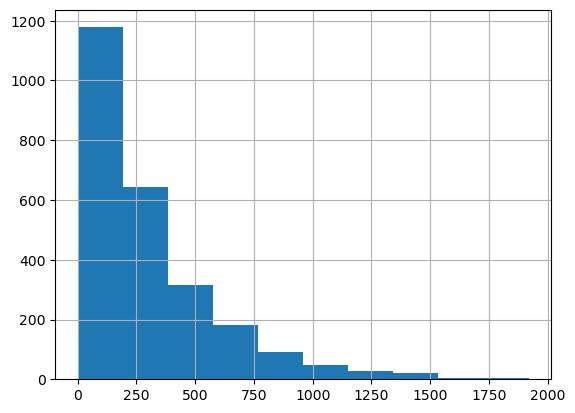

In [12]:
df['TransactionAmount'].hist()

In [26]:
# Select numerical features for anomaly detection, including new date/time components
features = [
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance',
    'TransactionYear',
    'TransactionMonth',
    'TransactionDay',
    'TransactionHourDecimal',
    'PrevTransactionHourDecimal'
]
X = df[features]

# Scale the features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
categorical_features = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation', 'MerchantID']
ohe = OneHotEncoder()
df_encoded = ohe.fit_transform(df[categorical_features])


# Initialize and train the Isolation Forest model
# contamination: The proportion of outliers in the data set. Here, assuming 1% outliers.
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X_scaled)

# Predict anomalies (-1 for outliers, 1 for inliers)
df['anomaly'] = model.predict(X_scaled)

# Add anomaly score to the DataFrame
df['anomaly_score'] = model.decision_function(X_scaled)

potential_frauds = df[df['anomaly'] == -1]
len(potential_frauds)

126

In [27]:
anomalies = df[df['anomaly'] == -1]
anomalies

,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,...,TransactionYear,TransactionMonth,TransactionDay,TransactionHourDecimal,PrevTransactionYear,PrevTransactionMonth,PrevTransactionDay,PrevTransactionHourDecimal,anomaly,anomaly_score
9,TX000010,AC00385,815.96,Debit,Nashville,D000199,32.169.88.41,M007,ATM,55,...,2023,3,31,16.115833,2024,11,4,8.108889,-1,-0.001082
23,TX000024,AC00453,345.84,Debit,Fort Worth,D000162,191.82.103.198,M083,Online,22,...,2023,5,2,18.429444,2024,11,4,8.117778,-1,-0.018681
26,TX000027,AC00441,246.93,Debit,Miami,D000046,55.154.161.250,M029,ATM,23,...,2023,4,17,16.616944,2024,11,4,8.193889,-1,-0.032947
85,TX000086,AC00098,1340.19,Credit,Austin,D000574,165.114.224.47,M012,Online,54,...,2023,9,29,17.369444,2024,11,4,8.114722,-1,-0.008107
91,TX000092,AC00310,223.85,Debit,Kansas City,D000481,133.223.159.151,M009,ATM,53,...,2023,10,2,16.602778,2024,11,4,8.133611,-1,-0.018171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2414,TX002415,AC00028,1664.33,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,18,...,2023,9,25,17.188611,2024,11,4,8.118611,-1,-0.028696
2421,TX002422,AC00152,29.92,Credit,Denver,D000672,167.95.191.52,M010,Online,68,...,2024,1,1,16.420278,2024,11,4,8.170833,-1,-0.010057
2423,TX002424,AC00340,332.06,Debit,Seattle,D000365,94.37.250.128,M086,ATM,29,...,2023,6,21,16.648333,2024,11,4,8.106389,-1,-0.047749
2445,TX002446,AC00439,403.01,Debit,Washington,D000677,223.32.70.156,M029,Online,63,...,2023,9,4,17.543056,2024,11,4,8.158889,-1,-0.027608


In [28]:
df['anomaly'].unique()

array([ 1, -1])

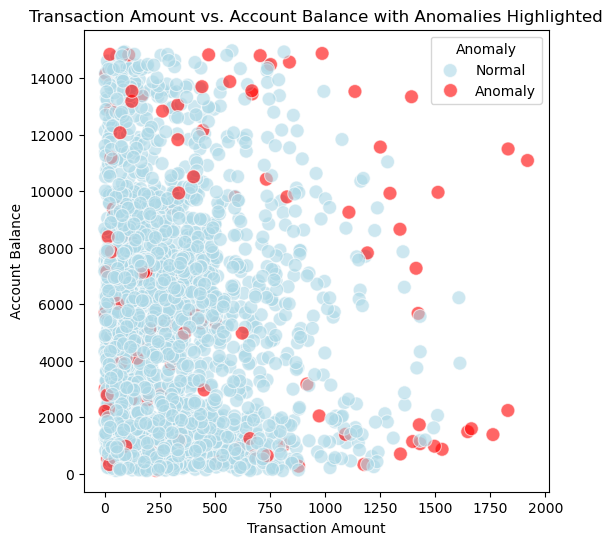

In [29]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x='TransactionAmount',
    y='AccountBalance',
    hue='anomaly',
    data=df,
    palette={1: 'lightblue', -1: 'red'},
    s=100,
    alpha=0.6
)
plt.title('Transaction Amount vs. Account Balance with Anomalies Highlighted')
plt.xlabel('Transaction Amount')
plt.ylabel('Account Balance')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
plt.show()